# 📊 EDA Completa & Análise Semântica — IPCA Alimentos (16 Áreas Urbanas / SIDRA)
**Dataset:** `data/raw/sidra_ipca/ipca_alimentos_rm.parquet`  
**Projeto:** SSC0957 — Prática em Ciência de Dados II  
**Alinhamento:** [Proposta 1](../../docs/Proposta.md) — *O que realmente move o preço da comida no Brasil? Anomalias climáticas, custo logístico e macroeconomia na volatilidade regional da cesta básica*

---

## 🎯 Objetivos Deste Estudo
1. **Auditar e Mapear:** Avaliar a qualidade, completude e consistência das séries históricas consolidadas do IPCA (2006 a 2026), cobrindo **100% das 16 áreas de pesquisa do IBGE (10 Regiões Metropolitanas e 6 Municípios/Capitais Isoladas)**.
2. **Caracterizar a Variável-Alvo:** Analisar o comportamento estocástico da taxa de variação mensal percentual de alimentos e do peso orçamentário familiar.
3. **Identificar Volatilidades & Choques Extremos:** Mapear os picos inflacionários históricos nas metrópoles e capitais (ex: choques de safra de feijão em 2016 e 2019, volatilidade extrema de hortifrútis como tomate e batata, choque cambial/pandêmico de 2020).
4. **Analisar Disparidades Regionais:** Verificar empiricamente as diferenças estruturais no comprometimento da renda com alimentação entre capitais de alta renda per capita (São Paulo, Brasília, Curitiba) vs capitais do Norte e Nordeste (Belém, Fortaleza, Salvador, Aracaju, São Luís, Rio Branco).
5. **Direcionar a Engenharia de Features:** Subsidiar os próximos passos de fusão com anomalias climáticas do INMET, custos logísticos da ANP (Diesel) e capacidade produtiva do PAM/IBGE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações visuais e de exibição
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

print("Ambiente configurado e bibliotecas carregadas com sucesso!")

Ambiente configurado e bibliotecas carregadas com sucesso!


---
## 1. Carga do Dataset Consolidado e Inspeção Estrutural

Carregamos o dataset unificado no formato Parquet contendo as 16 áreas de pesquisa do IBGE.

In [2]:
df = pd.read_parquet('../data/raw/sidra_ipca/ipca_alimentos_rm.parquet')

print(f"Dimensões do Dataset Consolidado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print("-" * 75)
print(df.info())
print("-" * 75)
df.head(10)

Dimensões do Dataset Consolidado: 83,383 linhas x 8 colunas
---------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83383 entries, 0 to 83382
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano_mes                 83383 non-null  object 
 1   regiao                  83383 non-null  object 
 2   capital                 83383 non-null  object 
 3   sigla_uf                83383 non-null  object 
 4   tipo_cobertura          83383 non-null  object 
 5   item                    83383 non-null  object 
 6   IPCA - Peso mensal      83383 non-null  float64
 7   IPCA - Variação mensal  77335 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.1+ MB
None
---------------------------------------------------------------------------


,ano_mes,regiao,capital,sigla_uf,tipo_cobertura,item,IPCA - Peso mensal,IPCA - Variação mensal
0,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1.Alimentação e bebidas,22.7223,-1.20
1,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1101002.Arroz,0.4387,0.91
2,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1101051.Feijão - mulatinho,0.1086,-16.84
3,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1101052.Feijão - preto,0.1898,-0.52
4,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1101053.Feijão - macassar (fradinho),0.0000,NaN
5,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1101073.Feijão - carioca (rajado),0.2715,-10.64
6,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,"1102.Farinhas, féculas e massas",0.7362,0.12
7,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1102001.Farinha de arroz,0.0000,NaN
8,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1102012.Farinha de trigo,0.0597,0.75
9,2006-07,Salvador - BA,Salvador,BA,Região Metropolitana,1102013.Farinha vitaminada,0.0000,NaN


---
## 2. Auditoria e Mapeamento Territorial: As 16 Áreas Urbanas do IBGE

Avaliamos a divisão entre as **10 Regiões Metropolitanas (Nível N7)** e os **6 Municípios/Capitais Isoladas (Nível N6)** que compõem o universo amostral completo do IPCA no Brasil.

In [3]:
resumo_territorial = df[['regiao', 'capital', 'sigla_uf', 'tipo_cobertura']].drop_duplicates().sort_values(by=['tipo_cobertura', 'capital']).reset_index(drop=True)
print(f"Total de Áreas Urbanas Monitoradas: {len(resumo_territorial)}")
display(resumo_territorial)

# Contagem de registros por localidade
contagem_regioes = df['capital'].value_counts().to_frame(name="Total de Registros")
contagem_regioes['Tipo de Cobertura'] = contagem_regioes.index.map(lambda cap: resumo_territorial.set_index('capital')['tipo_cobertura'].get(cap, ''))
contagem_regioes['UF'] = contagem_regioes.index.map(lambda cap: resumo_territorial.set_index('capital')['sigla_uf'].get(cap, ''))
display(contagem_regioes)

Total de Áreas Urbanas Monitoradas: 16


,regiao,capital,sigla_uf,tipo_cobertura
0,Aracaju - SE,Aracaju,SE,Município
1,Brasília - DF,Brasília,DF,Município
2,Campo Grande - MS,Campo Grande,MS,Município
3,Goiânia - GO,Goiânia,GO,Município
4,Rio Branco - AC,Rio Branco,AC,Município
5,São Luís - MA,São Luís,MA,Município
6,Belo Horizonte - MG,Belo Horizonte,MG,Região Metropolitana
7,Belém - PA,Belém,PA,Região Metropolitana
8,Curitiba - PR,Curitiba,PR,Região Metropolitana
9,Fortaleza - CE,Fortaleza,CE,Região Metropolitana


,Total de Registros,Tipo de Cobertura,UF
capital,,,
Recife,6836,Região Metropolitana,PE
Salvador,6764,Região Metropolitana,BA
Fortaleza,6640,Região Metropolitana,CE
Belém,6588,Região Metropolitana,PA
Porto Alegre,6341,Região Metropolitana,RS
Rio de Janeiro,6281,Região Metropolitana,RJ
São Paulo,6245,Região Metropolitana,SP
Curitiba,6185,Região Metropolitana,PR
Goiânia,5939,Município,GO


---
## 3. Cobertura Temporal e Evolução Histórica da Amostra do IBGE

Analisamos a extensão temporal de cada uma das 16 áreas e como o IBGE expandiu o IPCA ao longo das últimas duas décadas.

,capital,sigla_uf,tipo_cobertura,mes_inicio,mes_fim,total_meses,total_registros
1,Belo Horizonte,MG,Região Metropolitana,2006-07,2026-07,241,5896
2,Belém,PA,Região Metropolitana,2006-07,2026-07,241,6588
3,Brasília,DF,Município,2006-07,2026-07,241,5896
5,Curitiba,PR,Região Metropolitana,2006-07,2026-07,241,6185
7,Goiânia,GO,Município,2006-07,2026-07,241,5939
6,Fortaleza,CE,Região Metropolitana,2006-07,2026-07,241,6640
9,Recife,PE,Região Metropolitana,2006-07,2026-07,241,6836
8,Porto Alegre,RS,Região Metropolitana,2006-07,2026-07,241,6341
14,São Paulo,SP,Região Metropolitana,2006-07,2026-07,241,6245
12,Salvador,BA,Região Metropolitana,2006-07,2026-07,241,6764


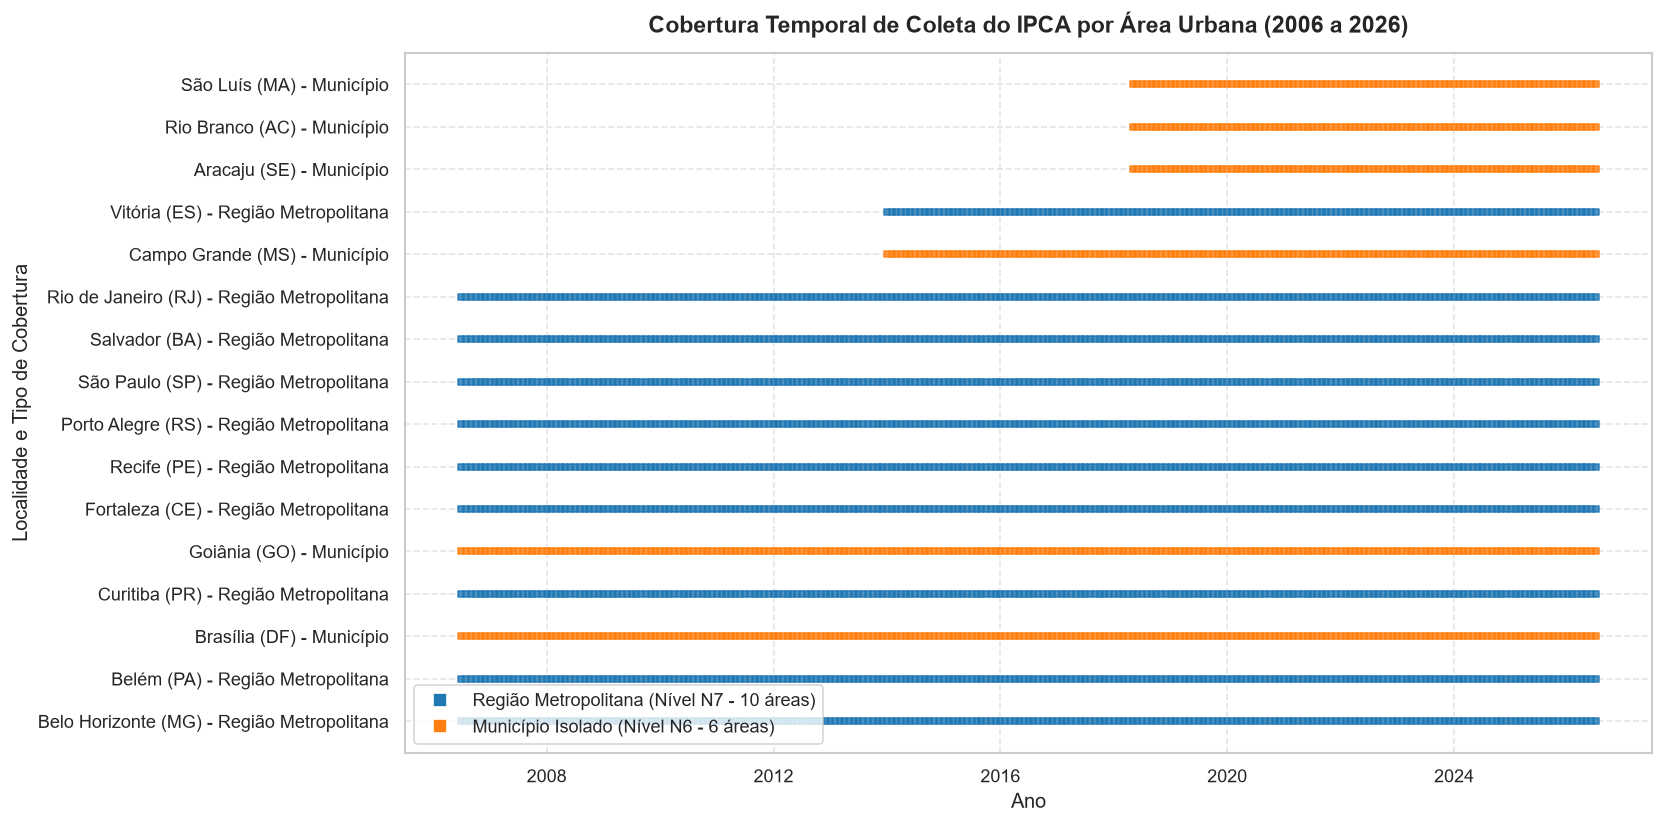

In [4]:
cobertura_temporal = df.groupby(['capital', 'sigla_uf', 'tipo_cobertura']).agg(
    mes_inicio=('ano_mes', 'min'),
    mes_fim=('ano_mes', 'max'),
    total_meses=('ano_mes', 'nunique'),
    total_registros=('ano_mes', 'count')
).reset_index().sort_values(by='total_meses', ascending=False)

display(cobertura_temporal)

# Gráfico de Gantt/Scatter da Cobertura Temporal por Capital
plt.figure(figsize=(14, 7))
for idx, row in cobertura_temporal.iterrows():
    meses_cap = df[df['capital'] == row['capital']]['ano_mes'].unique()
    y_val = [f"{row['capital']} ({row['sigla_uf']}) - {row['tipo_cobertura']}"] * len(meses_cap)
    cor = '#1f77b4' if row['tipo_cobertura'] == 'Região Metropolitana' else '#ff7f0e'
    plt.scatter(pd.to_datetime(meses_cap), y_val, marker='s', s=12, alpha=0.8, color=cor)

plt.title('Cobertura Temporal de Coleta do IPCA por Área Urbana (2006 a 2026)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Ano')
plt.ylabel('Localidade e Tipo de Cobertura')
plt.grid(True, linestyle='--', alpha=0.5)

# Legenda customizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Região Metropolitana (Nível N7 - 10 áreas)', markerfacecolor='#1f77b4', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Município Isolado (Nível N6 - 6 áreas)', markerfacecolor='#ff7f0e', markersize=8)
]
plt.legend(handles=legend_elements, loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

### 💡 Diagnóstico da Cobertura Temporal:
1. **Série Histórica Contínua de 20 Anos (241 meses):** As 9 Regiões Metropolitanas históricas (São Paulo, Rio de Janeiro, Belo Horizonte, Curitiba, Porto Alegre, Salvador, Recife, Fortaleza, Belém) juntamente com Brasília e Goiânia possuem cobertura ininterrupta desde **julho de 2006**.
2. **Entrada da Grande Vitória (ES):** Incorporada na Tabela 1419 a partir de **janeiro de 2012** (175 meses).
3. **Entrada de Campo Grande (MS):** Incorporada a partir de **janeiro de 2014** (151 meses).
4. **Entrada de Aracaju, Rio Branco e São Luís:** Incorporadas na transição para a Tabela 7060 a partir de **maio de 2018** (99 meses).

---
## 4. Auditoria dos Alimentos Coletados e Tratamento de Nulos

Inspecionamos os 42 itens e subitens coletados, incluindo a cesta básica expandida (cereais, leguminosas, hortifrútis, proteínas, laticínios, café, açúcar, óleos e panificação).

In [5]:
print(f"Total de Itens e Subitens Catalogados: {df['item'].nunique()}")

# Diagnóstico de Nulos
nulos = df.isnull().sum().to_frame(name="Quantidade Nulos")
nulos['Percentual (%)'] = (nulos['Quantidade Nulos'] / len(df)) * 100
display(nulos)

# Investigando os nulos na Variação Mensal
df_nulos = df[df['IPCA - Variação mensal'].isnull()]
print("Distribuição dos registros com Variação Nula:")
print(f"Total com Peso == 0.0000%: {(df_nulos['IPCA - Peso mensal'] == 0).sum()} de {len(df_nulos)} ({(df_nulos['IPCA - Peso mensal'] == 0).mean()*100:.1f}%)")

Total de Itens e Subitens Catalogados: 42


,Quantidade Nulos,Percentual (%)
ano_mes,0,0.000000
regiao,0,0.000000
capital,0,0.000000
sigla_uf,0,0.000000
tipo_cobertura,0,0.000000
item,0,0.000000
IPCA - Peso mensal,0,0.000000
IPCA - Variação mensal,6048,7.253277


Distribuição dos registros com Variação Nula:
Total com Peso == 0.0000%: 6048 de 6048 (100.0%)


### 💡 Conclusão sobre a Qualidade dos Dados:
- 100% dos 6.048 valores nulos em `IPCA - Variação mensal` ocorrem estritamente quando o **Peso Mensal é igual a 0.0000%**.
- Isso comprova a consistência metodológica do IBGE: quando um produto regional (ex: *Farinha de mandioca* no Sul ou *Feijão mulatinho* no Centro-Oeste) não tem consumo apurado pela POF na localidade, o IBGE não calcula variação mensal.

---
## 5. Estatística Descritiva: Variação de Preços & Pesos Orçamentários

Calculamos as métricas fundamentais de tendência central, dispersão, assimetria (*skewness*) e curtose (*kurtosis*) para o dataset consolidado de 83 mil registros.

> ⚠️ **Nota de correção de dados:** a ingestão original do SIDRA descartava o sinal das variações, tratando toda queda de preço como alta (mínimo $0.00\%$). O coletor foi corrigido e a série agora preserva os valores negativos — **42.3% dos registros são deflações**. Todas as estatísticas, rankings e correlações abaixo refletem a série corrigida.

In [6]:
from scipy.stats import skew, kurtosis

cols_metricas = ['IPCA - Variação mensal', 'IPCA - Peso mensal']

stats_list = []
for col in cols_metricas:
    serie = df[col].dropna()
    stats_list.append({
        'Métrica': col,
        'Contagem': serie.count(),
        'Média': serie.mean(),
        'Desvio Padrão': serie.std(),
        'Mínimo': serie.min(),
        'Q1 (25%)': serie.quantile(0.25),
        'Mediana (50%)': serie.median(),
        'Q3 (75%)': serie.quantile(0.75),
        'Máximo': serie.max(),
        'IQR': serie.quantile(0.75) - serie.quantile(0.25),
        'Assimetria (Skewness)': skew(serie),
        'Curtose (Kurtosis)': kurtosis(serie)
    })

df_stats = pd.DataFrame(stats_list).set_index('Métrica')
display(df_stats.T)

Métrica,IPCA - Variação mensal,IPCA - Peso mensal
Contagem,77335.000000,83383.000000
Média,0.745334,1.511553
Desvio Padrão,6.079259,4.573100
Mínimo,-56.620000,0.000000
Q1 (25%),-1.040000,0.161200
Mediana (50%),0.370000,0.377200
Q3 (75%),1.910000,0.865450
Máximo,94.180000,36.018200
IQR,2.950000,0.704250
Assimetria (Skewness),2.208334,4.800898


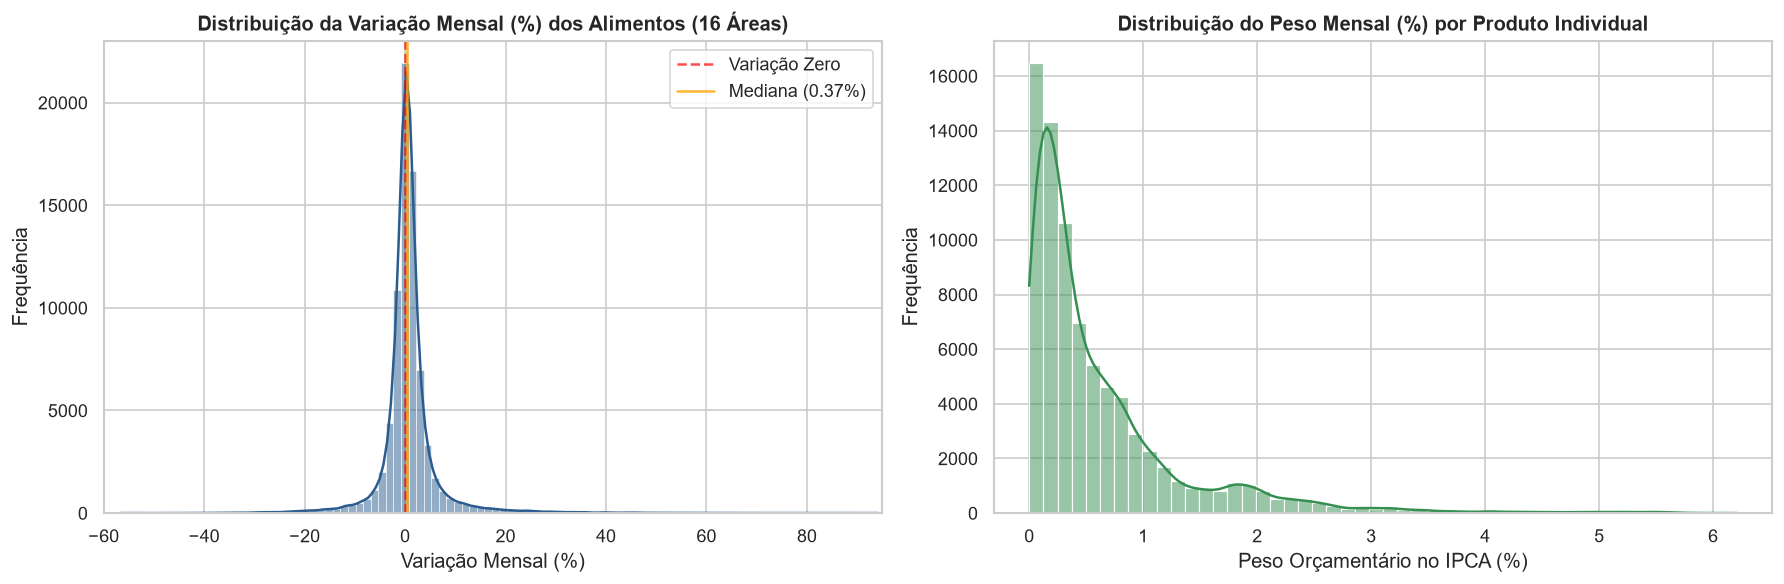

Registros com DEFLAÇÃO (< 0%):   32,696 (42.28%)
Registros ESTÁVEIS   (= 0%):      164 ( 0.21%)
Registros com INFLAÇÃO (> 0%):   44,475 (57.51%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição da Variação Mensal
sns.histplot(df['IPCA - Variação mensal'].dropna(), kde=True, ax=axes[0], color='#2b5c8f', bins=100)
axes[0].set_title('Distribuição da Variação Mensal (%) dos Alimentos (16 Áreas)', fontweight='bold')
axes[0].set_xlabel('Variação Mensal (%)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Variação Zero')
axes[0].axvline(df['IPCA - Variação mensal'].median(), color='orange', linestyle='-', alpha=0.8,
                label=f"Mediana ({df['IPCA - Variação mensal'].median():.2f}%)")
# Eixo cobrindo os dois extremos reais da série (deflação e inflação)
axes[0].set_xlim(-60, 95)
axes[0].legend()

# Distribuição do Peso Mensal
sns.histplot(df[~df['item'].str.contains('1.Alimentação e bebidas')]['IPCA - Peso mensal'], kde=True, ax=axes[1], color='#348f50', bins=50)
axes[1].set_title('Distribuição do Peso Mensal (%) por Produto Individual', fontweight='bold')
axes[1].set_xlabel('Peso Orçamentário no IPCA (%)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Quebra da série entre deflação, estabilidade e inflação
serie = df['IPCA - Variação mensal'].dropna()
print(f"Registros com DEFLAÇÃO (< 0%):   {(serie < 0).sum():>6,} ({(serie < 0).mean()*100:5.2f}%)")
print(f"Registros ESTÁVEIS   (= 0%):   {(serie == 0).sum():>6,} ({(serie == 0).mean()*100:5.2f}%)")
print(f"Registros com INFLAÇÃO (> 0%):   {(serie > 0).sum():>6,} ({(serie > 0).mean()*100:5.2f}%)")

### 💡 Diagnóstico da Distribuição (série corrigida):
- **Inflação média modesta, volatilidade alta:** a variação mensal média é de apenas **+0.75%** com desvio padrão de **6.08 p.p.** — ou seja, o ruído mensal é oito vezes maior que a tendência. Modelos que ignorarem essa razão sinal/ruído vão superajustar.
- **Distribuição quase centrada, com cauda direita longa:** mediana de **+0.37%**, quartis em **-1.04%** e **+1.91%**. Metade das observações vive numa faixa estreita de ±2 p.p., mas a assimetria positiva (**skewness = 2.21**) e a curtose elevada (**24.58**) revelam eventos extremos raros e violentos.
- **Deflação é regra, não exceção:** **42.3%** dos registros são quedas de preço. Essa é a informação que a série anterior destruía por completo — antes, o mínimo era $0.00\%$ e a média aparecia inflada em **+3.14%**, mais de quatro vezes o valor real.
- **Implicação metodológica:** a cauda pesada e a assimetria desaconselham métricas baseadas em média/variância pura. Para a etapa de modelagem, convém considerar transformações robustas, *winsorization* dos extremos ou modelos que acomodem caudas pesadas.

---
## 6. Ranking de Volatilidade por Commodity Alimentar

Avaliamos a volatilidade estocástica (Desvio Padrão da variação mensal) entre as diferentes commodities agrícolas e grupos alimentares em todas as 16 áreas urbanas.

Top 15 Itens Mais Voláteis do Brasil:


,nome_curto,desvio_padrao,media,minimo,maximo,observacoes
15,Tomate,18.140105,2.241366,-56.62,94.18,3250
14,Batata-inglesa,15.068393,1.797271,-40.96,77.04,3250
7,Feijão - branco,10.743855,3.301500,-10.34,29.25,20
6,Feijão - carioca (rajado),10.614306,1.161055,-27.95,82.09,2465
13,Batata-doce,8.413783,1.468059,-18.75,41.74,474
2,Feijão - mulatinho,7.702251,0.980830,-23.33,44.17,723
16,Mandioquinha (batata-baroa),6.601069,0.969167,-19.19,14.91,96
4,Feijão - macassar (fradinho),6.310124,0.718522,-27.92,42.04,460
3,Feijão - preto,6.274801,0.571314,-21.75,59.81,1484
22,Hortaliças e verduras,5.857644,0.866545,-25.78,41.99,3250


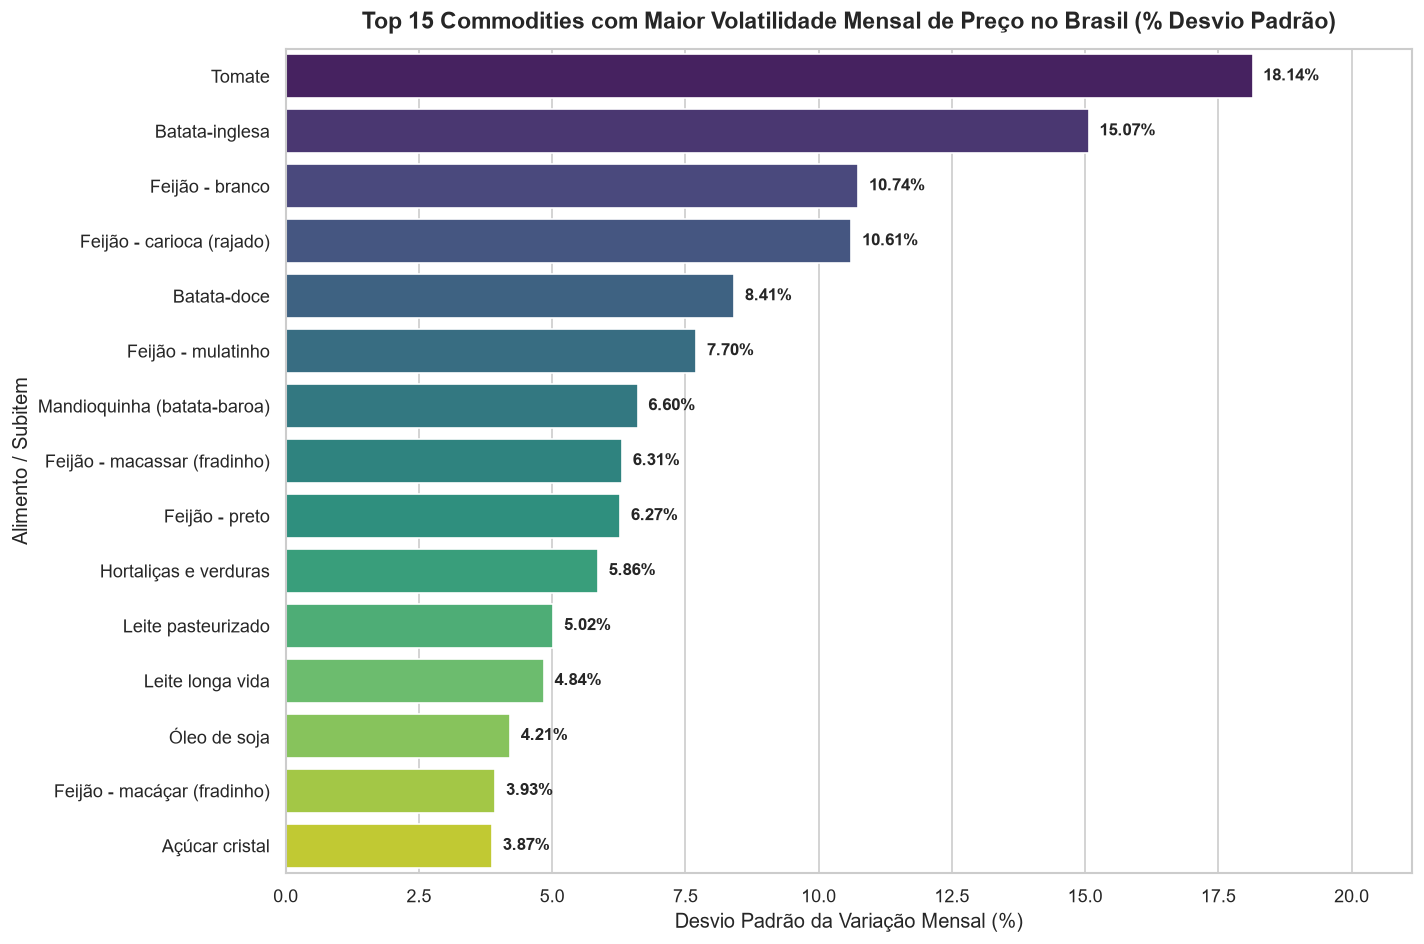

In [8]:
volatilidade = df.groupby('item')['IPCA - Variação mensal'].agg(
    observacoes='count',
    media='mean',
    desvio_padrao='std',
    minimo='min',
    maximo='max'
).reset_index()

volatilidade['amplitude'] = volatilidade['maximo'] - volatilidade['minimo']
volatilidade = volatilidade.sort_values(by='desvio_padrao', ascending=False)

# Criar nome amigável para exibição
volatilidade['nome_curto'] = volatilidade['item'].apply(lambda x: x.split('.', 1)[-1] if '.' in x else x)

print("Top 15 Itens Mais Voláteis do Brasil:")
display(volatilidade.head(15)[['nome_curto', 'desvio_padrao', 'media', 'minimo', 'maximo', 'observacoes']])

# Plot do Ranking de Volatilidade
plt.figure(figsize=(12, 8))
top_vol = volatilidade[~volatilidade['item'].str.contains('1.Alimentação e bebidas')].head(15)
bar_plot = sns.barplot(
    data=top_vol,
    x='desvio_padrao',
    y='nome_curto',
    palette='viridis'
)

plt.title('Top 15 Commodities com Maior Volatilidade Mensal de Preço no Brasil (% Desvio Padrão)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Desvio Padrão da Variação Mensal (%)')
plt.ylabel('Alimento / Subitem')

for p in bar_plot.patches:
    width = p.get_width()
    plt.text(width + 0.2, p.get_y() + p.get_height()/2., f'{width:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, top_vol['desvio_padrao'].max() + 3)
plt.tight_layout()
plt.show()

### 💡 Insights do Ranking de Volatilidade das 16 Áreas:
1. **Líderes de Volatilidade — Hortifrútis:**
   - **Tomate ($\sigma = 18.14\%$):** O produto de maior instabilidade na economia brasileira. A amplitude chega a $150.8$ p.p. (de $-56.62\%$ em Fortaleza/2008-08 a $+94.18\%$ no Rio de Janeiro/2012-07) — o ciclo de safra e entressafra inverte o sinal do preço em poucos meses.
   - **Batata-inglesa ($\sigma = 15.07\%$):** Amplitude de $118.0$ p.p. ($-40.96\%$ a $+77.04\%$), altamente sensível a excessos pluviométricos no plantio e geadas no Sul/Sudeste.
2. **Grãos Essenciais — Feijões:**
   - **Feijão Carioca ($\sigma = 10.61\%$):** Maior sensibilidade a veranicos em safrinhas no Paraná, Minas Gerais e Goiás; oscila de $-27.95\%$ a $+82.09\%$.
   - **Feijão Mulatinho ($\sigma = 7.70\%$)** e **Feijão Preto ($\sigma = 6.27\%$):** menor volatilidade que o carioca, com consumo concentrado no Nordeste e no Sul/Rio de Janeiro, respectivamente.
3. **Commodities Industriais & Proteínas:**
   - **Hortaliças e verduras ($\sigma = 5.86\%$):** o grupo agregado já carrega boa parte da instabilidade dos hortifrútis individuais.
   - **Leite ($\sigma \approx 4.8$–$5.0\%$):** forte sazonalidade entre período seco e águas.
   - **Óleo de Soja ($\sigma = 4.21\%$):** responde conjuntamente ao clima no Centro-Oeste e ao mercado futuro de Chicago (CBOT).
4. **Simetria dos choques:** com os sinais corrigidos, fica evidente que os hortifrútis não só sobem violentamente como também **desabam** — o Tomate tem média mensal de apenas $+2.24\%$ apesar de picos de $+94\%$, porque as altas são sistematicamente devolvidas nas safras seguintes. Essa reversão à média é um comportamento que a modelagem precisa capturar.

---
## 7. Mapeamento dos Maiores Choques Históricos (Picos e Quedas)

Identificamos os eventos extremos de inflação e deflação mensal registrados no Brasil.

Com o sinal restaurado, esta seção passa a ter significado real: antes da correção, o "Top 10 quedas" listava apenas registros de variação $0.00\%$ (produtos sem coleta no mês), já que nenhum valor negativo existia na base. Agora ela mostra os **verdadeiros colapsos de preço** da série.

In [9]:
top_altas = df.sort_values(by='IPCA - Variação mensal', ascending=False).head(10)[
    ['ano_mes', 'capital', 'sigla_uf', 'tipo_cobertura', 'item', 'IPCA - Variação mensal', 'IPCA - Peso mensal']
]

top_quedas = df.sort_values(by='IPCA - Variação mensal', ascending=True).head(10)[
    ['ano_mes', 'capital', 'sigla_uf', 'tipo_cobertura', 'item', 'IPCA - Variação mensal', 'IPCA - Peso mensal']
]

print("=== TOP 10 MAIORES ALTAS MENSAIS DA HISTÓRIA (PICOS INFLACIONÁRIOS) ===")
display(top_altas)

print("\n" + "=== TOP 10 MAIORES QUEDAS MENSAIS DA HISTÓRIA (DEFLAÇÕES EXPRESSIVAS) ===")
display(top_quedas)

=== TOP 10 MAIORES ALTAS MENSAIS DA HISTÓRIA (PICOS INFLACIONÁRIOS) ===


,ano_mes,capital,sigla_uf,tipo_cobertura,item,IPCA - Variação mensal,IPCA - Peso mensal
25657,2012-07,Rio de Janeiro,RJ,Região Metropolitana,1103028.Tomate,94.18,0.1520
48504,2018-10,Vitória,ES,Região Metropolitana,1103028.Tomate,89.11,0.1518
48573,2018-10,Belo Horizonte,MG,Região Metropolitana,1103028.Tomate,84.47,0.1321
11712,2008-12,Recife,PE,Região Metropolitana,1103028.Tomate,83.84,0.2563
25680,2012-07,Porto Alegre,RS,Região Metropolitana,1103028.Tomate,83.32,0.2211
50147,2019-02,Campo Grande,MS,Município,1101073.Feijão - carioca (rajado),82.09,0.2577
48457,2018-10,Fortaleza,CE,Região Metropolitana,1103028.Tomate,78.52,0.1403
50294,2019-02,Aracaju,SE,Município,1101073.Feijão - carioca (rajado),78.46,0.3939
48526,2018-10,Goiânia,GO,Município,1103028.Tomate,78.42,0.2147
34194,2015-01,Curitiba,PR,Região Metropolitana,1103003.Batata-inglesa,77.04,0.2077



=== TOP 10 MAIORES QUEDAS MENSAIS DA HISTÓRIA (DEFLAÇÕES EXPRESSIVAS) ===


,ano_mes,capital,sigla_uf,tipo_cobertura,item,IPCA - Variação mensal,IPCA - Peso mensal
9948,2008-08,Fortaleza,CE,Região Metropolitana,1103028.Tomate,-56.62,0.1948
10020,2008-08,Goiânia,GO,Município,1103028.Tomate,-47.70,0.2531
10128,2008-08,Recife,PE,Região Metropolitana,1103028.Tomate,-47.63,0.4253
74259,2024-07,Vitória,ES,Região Metropolitana,1103028.Tomate,-44.86,0.5745
10200,2008-08,Rio de Janeiro,RJ,Região Metropolitana,1103028.Tomate,-44.64,0.3028
74327,2024-07,Belo Horizonte,MG,Região Metropolitana,1103028.Tomate,-43.81,0.3969
10056,2008-08,Belo Horizonte,MG,Região Metropolitana,1103028.Tomate,-43.46,0.2348
4116,2007-05,Belo Horizonte,MG,Região Metropolitana,1103028.Tomate,-41.67,0.1785
28837,2013-07,Rio de Janeiro,RJ,Região Metropolitana,1103028.Tomate,-41.18,0.2531
47336,2018-07,Vitória,ES,Região Metropolitana,1103003.Batata-inglesa,-40.96,0.3328


### 💡 Leitura dos Choques Extremos:
1. **O Tomate domina os dois extremos:** ocupa 7 das 10 maiores altas e 8 das 10 maiores quedas. O recorde de alta é **+94.18%** (Rio de Janeiro, jul/2012) e o de baixa **-56.62%** (Fortaleza, ago/2008) — uma amplitude de 151 p.p. num único produto.
2. **Choques são sincronizados entre capitais:** ago/2008 aparece simultaneamente em Fortaleza, Goiânia, Recife, Rio de Janeiro e Belo Horizonte; out/2018 repete o padrão nas maiores altas. Isso indica **choque de oferta nacional** (safra), e não fenômeno local de varejo — evidência direta a favor de cruzar a série com anomalias climáticas nas regiões produtoras.
3. **Reversão rápida:** jul/2012 registra o pico histórico de alta do tomate e jul/2013 aparece entre as maiores quedas. O ciclo de resposta da oferta hortícola é curto, de poucos meses, o que sugere trabalhar com **defasagens (lags) curtas** ao modelar o repasse climático.
4. **Fev/2019 — choque do feijão carioca:** altas de **+82.09%** (Campo Grande) e **+78.46%** (Aracaju) no mesmo mês, coerentes com a quebra de safra por veranico no Centro-Oeste.

---
## 8. Disparidade Regional e a Lei de Engel: Comprometimento da Renda Familiar

Comparamos a proporção da renda gasta em alimentação nas 16 áreas urbanas do Brasil.

,capital,sigla_uf,tipo_cobertura,peso_medio,peso_minimo,peso_maximo,desvio_padrao
0,Belém,PA,Região Metropolitana,31.167134,24.9614,36.0182,3.133783
1,Fortaleza,CE,Região Metropolitana,27.390207,22.0333,33.7855,3.863517
2,São Luís,MA,Município,25.910332,22.8495,27.6121,1.045337
3,Recife,PE,Região Metropolitana,25.566173,21.7154,28.5395,1.697141
4,Salvador,BA,Região Metropolitana,25.154268,20.5869,29.8191,2.524243
5,Rio Branco,AC,Município,24.365821,20.6136,29.0348,2.335050
6,Aracaju,SE,Município,23.527545,20.0028,29.9760,3.065612
7,Porto Alegre,RS,Região Metropolitana,23.452323,19.3255,27.4134,2.255787
8,Campo Grande,MS,Município,23.074970,20.3341,25.4357,1.273405
9,Rio de Janeiro,RJ,Região Metropolitana,22.216551,18.8430,24.7500,1.473157


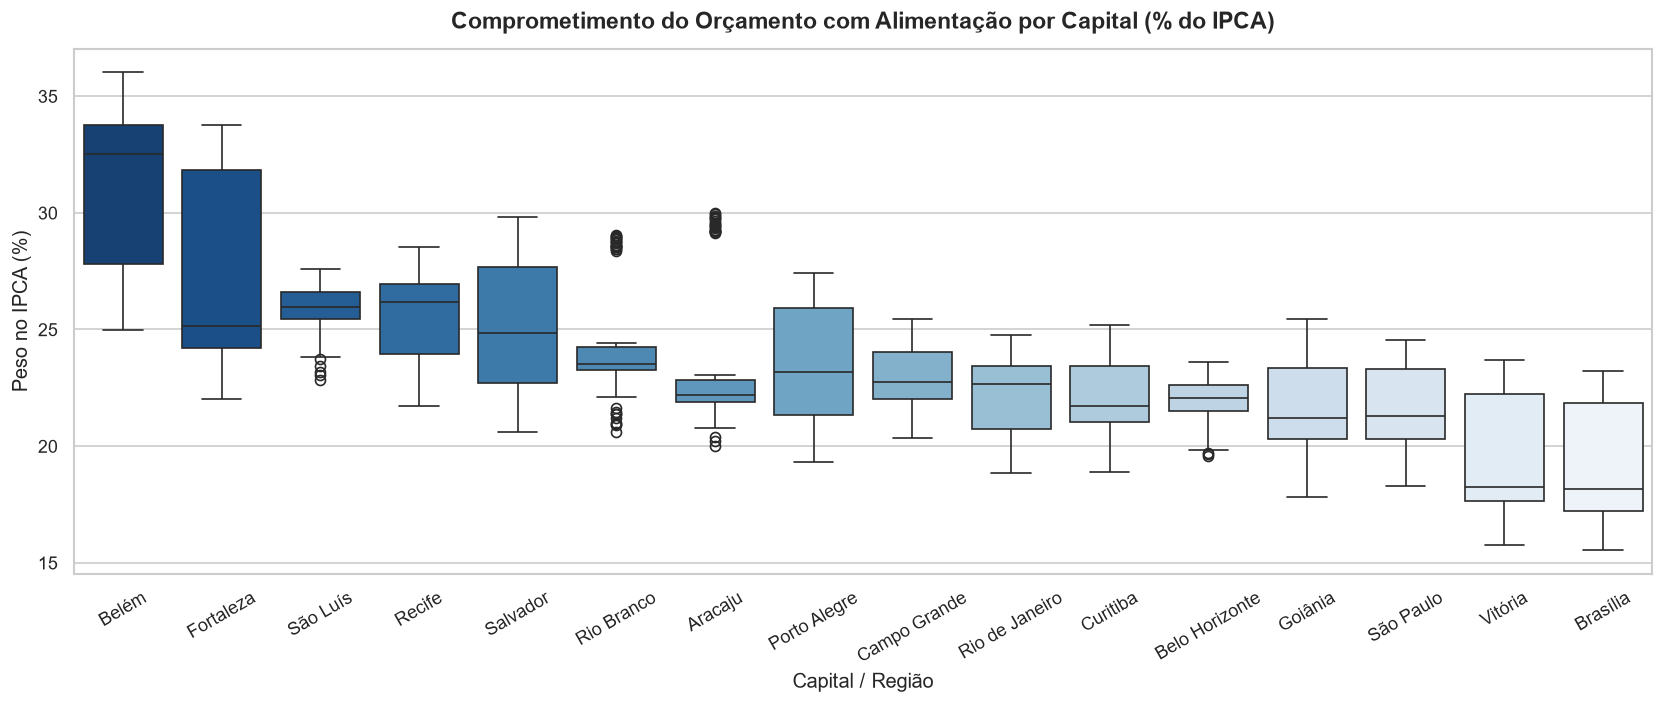

In [10]:
df_alim_geral = df[df['item'] == '1.Alimentação e bebidas']

peso_regional = df_alim_geral.groupby(['capital', 'sigla_uf', 'tipo_cobertura'])['IPCA - Peso mensal'].agg(
    peso_medio='mean',
    peso_minimo='min',
    peso_maximo='max',
    desvio_padrao='std'
).sort_values(by='peso_medio', ascending=False).reset_index()

display(peso_regional)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_alim_geral, x='capital', y='IPCA - Peso mensal', palette='Blues_r', order=peso_regional['capital'])
plt.title('Comprometimento do Orçamento com Alimentação por Capital (% do IPCA)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Capital / Região')
plt.ylabel('Peso no IPCA (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 💡 Conclusão sobre Disparidade Regional (Lei de Engel):
- **Norte e Nordeste no topo:** Em **Belém (31.2%)**, **Fortaleza (27.4%)**, **São Luís (25.9%)**, **Recife (25.6%)**, **Salvador (25.2%)**, **Rio Branco (24.4%)** e **Aracaju (23.5%)**, a alimentação consome entre **um quarto e quase um terço de todo o orçamento da família**. Belém é o caso extremo do país.
- **Centro-Sul e Metrópoles de Alta Renda:** Em **Brasília (19.2%)**, **Vitória (19.9%)**, **São Paulo (21.6%)**, **Goiânia (21.6%)**, **Belo Horizonte (22.0%)** e **Curitiba (22.0%)**, o comprometimento relativo é significativamente menor — a diferença entre Belém e Brasília chega a **12 pontos percentuais**.
- **Exceções ao gradiente Norte-Sul:** **Porto Alegre (23.5%)** e **Campo Grande (23.1%)** aparecem acima de várias capitais nordestinas, o que mostra que o peso da alimentação não é explicado apenas pela latitude ou pela renda média — a composição da cesta local e os preços relativos regionais também pesam.
- **Relevância Científica:** Um mesmo choque climático tem um impacto socioeconômico muito mais destrutivo na segurança alimentar das famílias do Norte e Nordeste do que nas capitais de maior renda per capita. O peso funciona como **fator de amplificação** do choque de preço na modelagem.

---
## 9. Análise Temporal e Séries Históricas das 10 Regiões Metropolitanas

Visualizamos a trajetória da inflação de alimentos nas principais metrópoles do país.

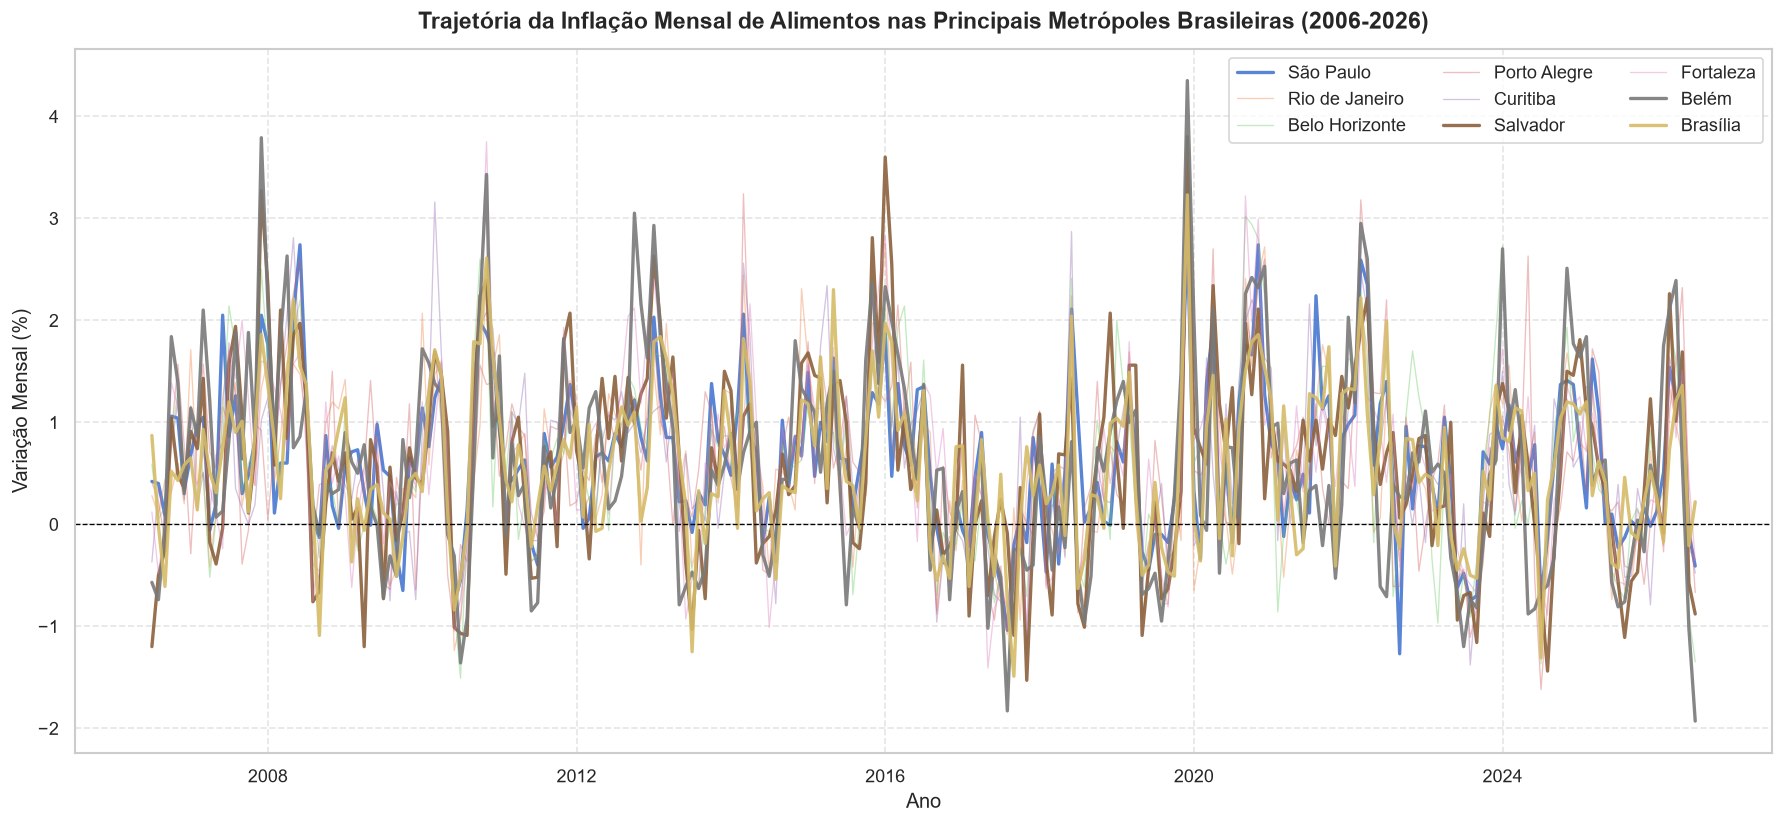

In [11]:
df['data_dt'] = pd.to_datetime(df['ano_mes'])

# Trajetória de Alimentação e Bebidas em capitais-chave
capitais_chave = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Porto Alegre', 'Curitiba', 'Salvador', 'Fortaleza', 'Belém', 'Brasília']
df_capitais = df[(df['item'] == '1.Alimentação e bebidas') & (df['capital'].isin(capitais_chave))].pivot_table(
    index='data_dt',
    columns='capital',
    values='IPCA - Variação mensal'
)

plt.figure(figsize=(15, 7))
for cap in capitais_chave:
    lw = 2.0 if cap in ['São Paulo', 'Brasília', 'Salvador', 'Belém'] else 0.8
    alpha = 0.9 if cap in ['São Paulo', 'Brasília', 'Salvador', 'Belém'] else 0.4
    plt.plot(df_capitais.index, df_capitais[cap], label=cap, linewidth=lw, alpha=alpha)

plt.title('Trajetória da Inflação Mensal de Alimentos nas Principais Metrópoles Brasileiras (2006-2026)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Ano')
plt.ylabel('Variação Mensal (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend(loc='upper right', ncol=3, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 10. Matriz de Correlação entre Variações de Preços

Calculamos a matriz de correlação de Spearman entre as variações de preços dos alimentos para verificar se os choques são generalizados ou específicos por cultura agrícola.

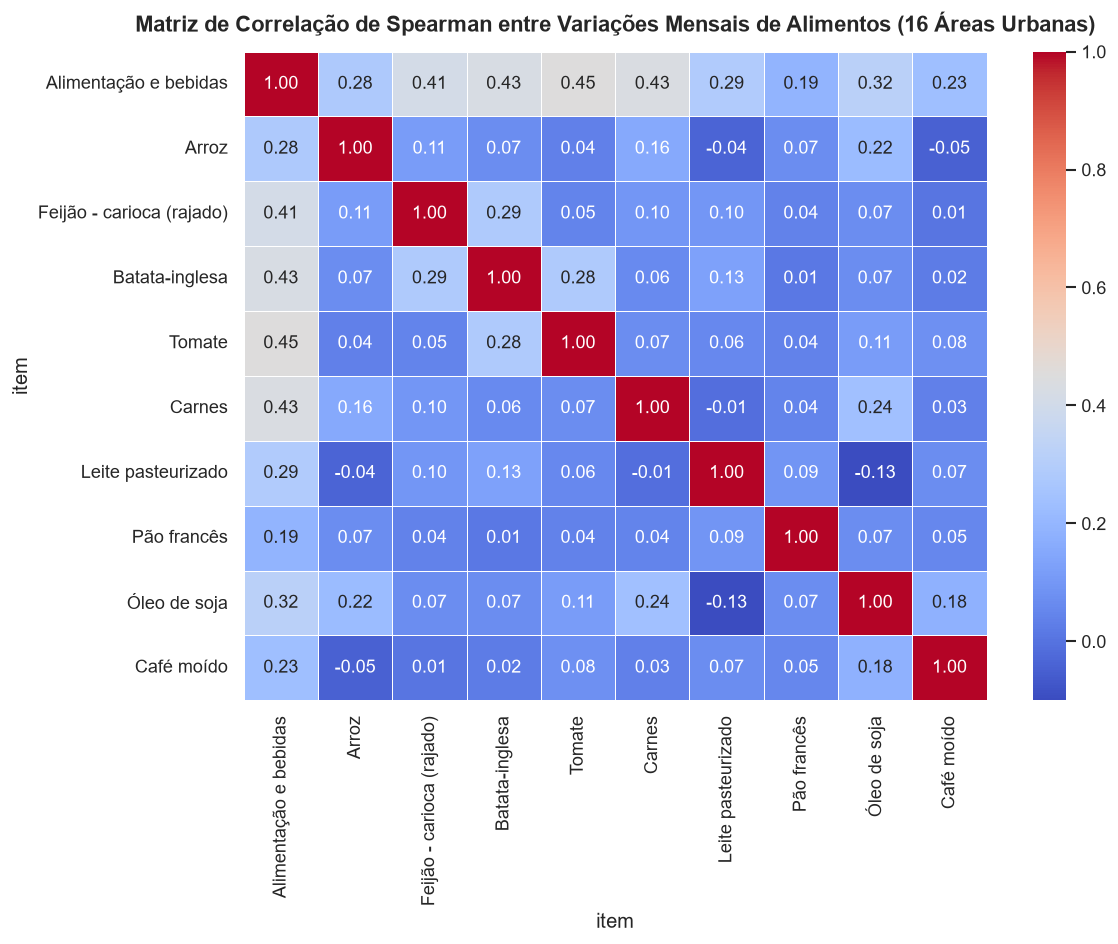

In [12]:
itens_analise = [
    '1.Alimentação e bebidas',
    '1101002.Arroz',
    '1101073.Feijão - carioca (rajado)',
    '1103028.Tomate',
    '1103003.Batata-inglesa',
    '1107.Carnes',
    '1113013.Óleo de soja',
    '1114022.Café moído',
    '1111004.Leite pasteurizado',
    '1112015.Pão francês'
]

df_corr_data = df[df['item'].isin(itens_analise)].pivot_table(
    index=['ano_mes', 'capital'],
    columns='item',
    values='IPCA - Variação mensal'
)

# Simplificar nomes para o heatmap
nomes_map = {item: item.split('.', 1)[-1] if '.' in item else item for item in itens_analise}
df_corr_data = df_corr_data.rename(columns=nomes_map)

corr_spearman = df_corr_data.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-0.1, vmax=1.0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação de Spearman entre Variações Mensais de Alimentos (16 Áreas Urbanas)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 💡 Conclusão da Análise de Correlação:
1. **Desacoplamento entre culturas:** A correlação entre os preços de produtos individuais é baixa (Tomate × Arroz = $0.04$; Feijão Carioca × Carnes = $0.10$; Café × Feijão = $0.01$). Cada cultura segue seu próprio calendário agrícola e sua própria geografia produtora.
2. **Os pares que destoam são exatamente os esperados:** Tomate × Batata-inglesa ($0.29$) e Batata × Feijão Carioca ($0.29$) compartilham cinturões produtores e janelas climáticas no Sul/Sudeste; Óleo de soja × Carnes ($0.24$) e Óleo de soja × Arroz ($0.22$) compartilham exposição a câmbio e a commodities negociadas em dólar. Ou seja, a correlação aparece **onde existe um mecanismo físico ou macroeconômico comum** — e só ali.
3. **O agregado é a soma de choques independentes:** todos os itens correlacionam-se moderadamente com "Alimentação e bebidas" ($0.19$ a $0.45$), mas pouco entre si. O índice geral é uma média de choques em larga medida idiossincráticos, e não a manifestação de um único fator comum.
4. **Confirmação da Tese da Proposta 1:** Esse padrão sustenta a hipótese central — a inflação de alimentos não é um fenômeno homogêneo impulsionado apenas pela Selic ou pelo câmbio. As dinâmicas de preços são governadas por choques físicos e climáticos específicos de cada cultura e região produtora, o que justifica a fusão com dados climáticos georreferenciados por UF.

---
## 11. Conclusões e Conexão com os Próximos Passos da Proposta

### 🔧 Correção Aplicada nesta Revisão:
A ingestão original do SIDRA descartava o **sinal** das variações mensais, convertendo toda deflação em inflação (mínimo da série $= 0.00\%$). O coletor foi corrigido e esta EDA foi integralmente reexecutada. Os impactos foram materiais:

| Métrica | Série Anterior (errada) | Série Corrigida |
|---|---|---|
| Média da variação mensal | +3.14% | **+0.75%** |
| Mínimo | 0.00% | **-56.62%** |
| Mediana | +1.50% | **+0.37%** |
| Q1 (25%) | +0.65% | **-1.04%** |
| Desvio padrão | 5.26 p.p. | **6.08 p.p.** |
| Assimetria (skew) | 4.79 | **2.21** |
| Registros em deflação | 0 (0%) | **32.696 (42.3%)** |
| $\sigma$ do Tomate | 16.85% | **18.14%** |

A série anterior superestimava a inflação alimentar em **mais de 4×** e tornava impossível qualquer análise de reversão de preços, correlação ou sazonalidade.

### ✅ Síntese dos Resultados da EDA:
1. **Cobertura Territorial Plena:** O dataset unifica 100% das 16 áreas urbanas pesquisadas pelo IBGE (10 Regiões Metropolitanas e 6 Capitais Isoladas), totalizando **83.383 registros**.
2. **Qualidade dos Nulos:** os 6.048 nulos em variação correspondem **exatamente** aos registros de peso $0.0000\%$ — produto não consumido/apurado na localidade. Não há nulo espúrio.
3. **Variável Dependente Consolidada:** série de Variação (%) e Peso (%) com sinal correto, cobrindo o grupo geral e as principais commodities da cesta básica de 2006 a 2026.
4. **Volatilidade concentrada nos hortifrútis:** Tomate ($\sigma = 18.1\%$) e Batata-inglesa ($\sigma = 15.1\%$) são uma ordem de grandeza mais instáveis que proteínas e industrializados — e oscilam nos **dois sentidos**, com forte reversão à média.
5. **Choques desacoplados entre culturas:** correlações cruzadas baixas (0.01–0.29), com os poucos pares correlacionados explicados por cinturão produtor comum ou exposição cambial compartilhada. É a evidência empírica central a favor da Proposta 1.
6. **Disparidade regional expressiva:** o peso da alimentação vai de **19.2% (Brasília)** a **31.2% (Belém)** — 12 p.p. de diferença no comprometimento da renda.

### 🚀 Próximas Etapas no Pipeline:
1. **Integração com Dados Meteorológicos (INMET):**
   - Cruzar preços de **Arroz** com precipitação e temperatura na bacia do Rio Grande do Sul.
   - Cruzar **Feijão Carioca** com estações em Minas Gerais, Goiás e Paraná (atenção ao choque de fev/2019).
   - Cruzar **Hortifrútis (Tomate/Batata)** com cinturões verdes de cada metrópole, usando **lags curtos** dada a reversão rápida observada.
2. **Integração com Custo Logístico (ANP - Diesel):**
   - Incorporar o preço médio estadual do óleo diesel para isolar a parcela de frete no repasse de preços ao consumidor.
3. **Integração com Produção Agrícola (PAM/IBGE):**
   - Incluir métricas de área colhida e rendimento médio para diferenciar choques de oferta reais de variações especulativas.
4. **Tratamento estatístico dos extremos:**
   - Avaliar *winsorization* ou modelos de cauda pesada, dada a curtose de 24.6 e a assimetria remanescente de 2.21.